In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
[NbConvertApp] WARNING | pattern 'lindbladian.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_c

In [39]:
# some installations
import sympy as sp
from sympy.physics.quantum.dagger import Dagger
from sympy.physics.quantum import TensorProduct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm, Normalize
from sympy.printing.mathematica import mathematica_code
from sympy.parsing.mathematica import parse_mathematica
import scipy
from lindbladian import *



In [61]:
# simulation parameters
time_start = 0
time_stop = 100000
time_step = 100
times = np.arange(time_start, time_stop, time_step)

# constants
J_val = 1e-4
epsilon_val = 1e-4

# number of sites
N = 4

# initial position

psi_0 = np.zeros(2**N)
# site 1 initially in equal superposition
psi_0[2**(N-1)]=1/np.sqrt(2)
psi_0[0]=1/np.sqrt(2)

'''
# site 1 initially excited
psi_0 = np.zeros(2**N)
psi_0[2**(N-1)]=1
'''

J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)

# building system hamiltonian
H_flipflop = sp.zeros(2**N, 2**N)
for j in range(N):
    for i in range(j):
        coeff = J if (i==0 and j==1) else epsilon
        H_flipflop += coeff*(sigma_plus(i,N)*sigma_minus(j,N)+sigma_plus(j,N)*sigma_minus(i,N))

In [62]:
Hz = sp.zeros(2**N, 2**N)
for j in range(N):
    for i in range(j):
        coeff = J if (i==0 and j==1) else epsilon
        Hz += coeff*(sigma(sigma_z, i, N)*sigma(sigma_z, j, N))

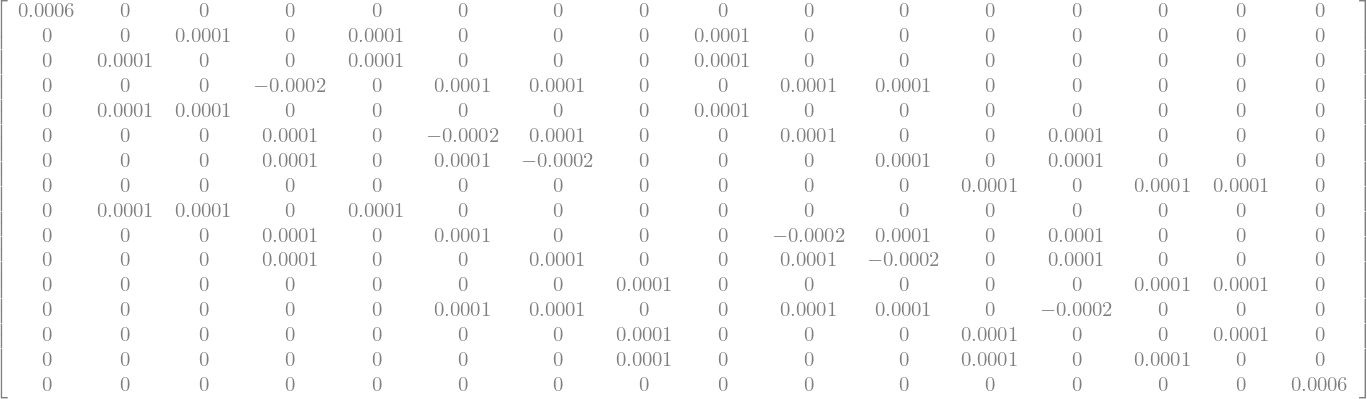

In [63]:
H_full = H_flipflop + Hz
H_full.subs({J:J_val, epsilon:epsilon_val})

In [64]:
# buildling matrices
sigma_z_1=np.array(sigma(sigma_z, 0, N)).astype(complex)
sigma_x_1=np.array(sigma(sigma_x, 0, N)).astype(complex)

# time evolution
def psi(t, H, psi_0):
    return scipy.linalg.expm(-1.0j*np.array(H).astype(complex)*t)@psi_0

/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


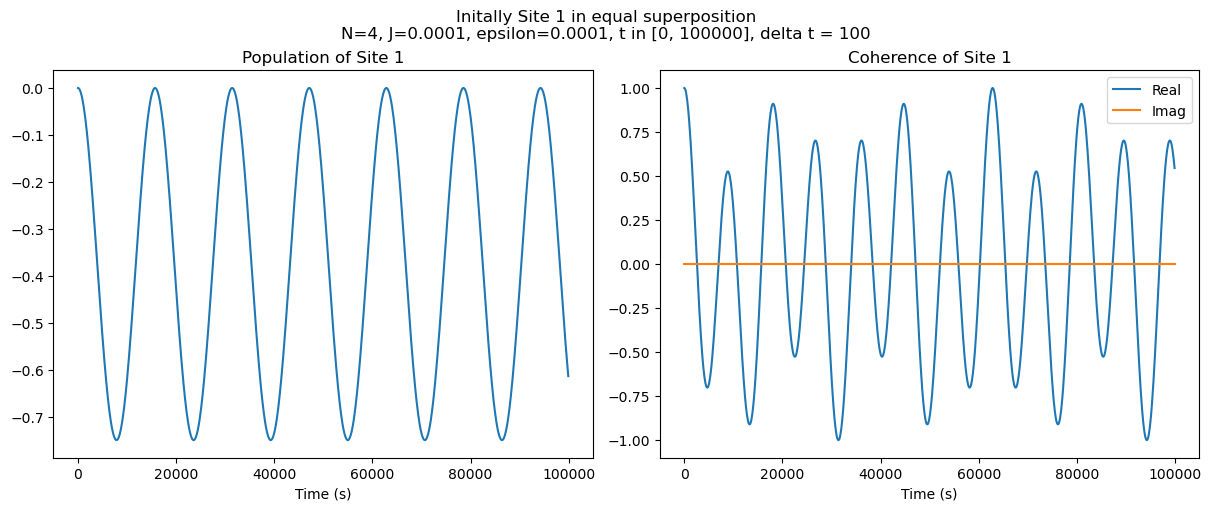

In [65]:
# subbing values into H
H = H_full.subs({J:J_val, epsilon:epsilon_val})

print

# setting up fig
fig, axs = plt.subplots(1,2, figsize=(12,5), layout="constrained")


# computing pops and cohs
pop1 = []
coh1 = []
for time in times:
    pop1.append(-1*psi(time, H, psi_0).conj().transpose()@sigma_z_1@psi(time, H, psi_0))
    coh1.append(psi(time, H, psi_0).conj().transpose()@sigma_x_1@psi(time, H, psi_0))


# plotting
axs[0].plot(times, pop1, label="100")
axs[0].set_xlabel("Time (s)")
#axs[0].legend(title="Site:")
axs[0].set_title("Population of Site 1")
axs[1].plot(times, np.real(coh1), label="Real")
axs[1].plot(times, np.imag(coh1), label="Imag")
axs[1].set_xlabel("Time (s)")
axs[1].legend()
#axs[1].ticklabel_format(axis='x', style='sci', scilimits=(0, 0)) 
axs[1].set_title("Coherence of Site 1")

fig.suptitle("Initally Site 1 in equal superposition" + "\n" + f"N={N}, J={J_val}, epsilon={epsilon_val}, t in [{time_start}, {time_stop}], delta t = {time_step}")

fig.savefig(f"N={N};J={J_val};epsilon={epsilon_val};[{time_start},{time_stop}];deltat={time_step}.pdf")

# saving as .dat files
np.savetxt( f"N={N};J={J_val};epsilon={epsilon_val};[{time_start},{time_stop}];deltat={time_step}.dat", np.array([times, pop1, coh1]).transpose() )


In [75]:
# saving as .py files
!jupyter nbconvert "[[]6.1.1] [[]july 23].ipynb" --TagRemovePreprocessor.enabled=True --TagRemovePreprocessor.remove_cell_tags="['ipnyb only']" --to script
!jupyter nbconvert "/home/jovyan/NSERC 2026/[[]1] [[]lindbladian helper code] [[]may 19]/lindbladian.ipynb" --output-dir="." --TagRemovePreprocessor.enabled=True --TagRemovePreprocessor.remove_cell_tags="['ipnyb only']" --to script



[NbConvertApp] Converting notebook [6.1.1] [july 23].ipynb to script
[NbConvertApp] Writing 3126 bytes to [6.1.1] [july 23].py
[NbConvertApp] Converting notebook /home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb to script
[NbConvertApp] Writing 11972 bytes to lindbladian.py


In [8]:
mathematica_code(H_full).replace("Gamma","Γ").replace("epsilon", "ϵ")

'{{J + 2*ϵ, 0, 0, 0, 0, 0, 0, 0}, {0, J - 2*ϵ, ϵ, 0, ϵ, 0, 0, 0}, {0, ϵ, -J, 0, J, 0, 0, 0}, {0, 0, 0, -J, 0, J, ϵ, 0}, {0, ϵ, J, 0, -J, 0, 0, 0}, {0, 0, 0, J, 0, -J, ϵ, 0}, {0, 0, 0, ϵ, 0, ϵ, J - 2*ϵ, 0}, {0, 0, 0, 0, 0, 0, 0, J + 2*ϵ}}'

In [141]:
psi(1, H, psi_0).conj().transpose()@sigma_z_1@psi(1, H, psi_0)

np.complex128(0.009966750515141783+0j)

In [136]:
H@psi_0

array([0.0717006276123159, 7.07106781186548e-5, 7.07106781186548e-5, 0,
       7.07106781186548e-5, 0, 0, 0, 7.07106781186548e-5, 0, 0, 0, 0, 0,
       0, 0, 0.0707106781186548, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, -0.0702864140499428, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object)

array([0.70710678, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.70710678, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])